# Assignment 10

### <span style="color:chocolate"> Submission requirements </span>

Your work will not be graded if your notebook doesn't include output. In other words, <span style="color:red"> make sure to rerun your notebook before submitting to Gradescope </span> (Note: if you are using Google Colab: go to Edit > Notebook Settings  and uncheck Omit code cell output when saving this notebook, otherwise the output is not printed).

Additional points may be deducted if these requirements are not met:
    
* Comment your code;
* Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own;
* Try and minimize the use of the global namespace (meaning, keep things inside functions).

---

#### ``Objectives``
1. Implement a CNN to detect diabetic retinopathy (DR) from retina images taken using fundus photography under a variety of imaging conditions.
2. Improve generalization performance and reduce overfitting using **image transformation** and **data augmentation** techniques.

#### ``Motivation``

Diabetic retinopathy (DR) is an eye condition that  affects blood vessels in the retina. It can cause vision loss and blindness in people who have diabetes. Screening for DR allows earlier and more effective treatment options for millions of people.

#### ``Data``

In this assignment you will use a small dataset of retina images (`Download` links: [images](https://drive.google.com/drive/folders/1sdfUC64Un1iwuiHEehcbijxB54OhU_nd?usp=sharing) and [labels](https://drive.google.com/drive/folders/1MOlSJBZg7L1HtG5vHPt77ighRvQaGfDg?usp=sharing)). You will **build** and **train** a **CNN model** to predict whether or not to refer a patient for DR treatment using binarized severity of DR in patients: no referral if {No DR, mild} and referral if {moderate, severe, and proliferate DR}.


<u>Note</u>: the original dataset is hosted by Kaggle [[Source]](https://www.kaggle.com/c/aptos2019-blindness-detection/).

Import the necessary libraries and make sure to replace IMAGE_PATH and LABEL_PATH with the path to the directories where you saved the data.

---
### Step 1: Import libraries

In [189]:
# standard
import pandas as pd
import numpy as np
import random
import os

# tf and keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from keras import models
from keras import layers

# sklearn
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# plots
import seaborn as sns
import matplotlib.pyplot as plt

random.seed(2)
%matplotlib inline

# FILL IN CODE HERE #
IMAGE_PATH = './images/' # replaced with my path
LABEL_PATH = './labels/' # replaced with my path

At this point, you may ask yourself what the best model that fits this data is. First, you will want to read through the data description in Kaggle (see the link to the original dataset above). Understanding what you are working with challenges you to write preprocessing code that uncovers your data's most helpful information.

---
#### <span style="color:chocolate"> Exercise 1 (10 points) </span>

Read the data description from Kaggle and list (a) the source of images and (b) the labeling procedure.

*Written answer*:

##### Answer
 - A) Source: In an effort to improve (automate and expedite) detection and prevention of diabetic retinopathy (DR), Aravind Eye Hospital sent technicians to rural areas in Inida to take medical images of patients' eyeballs and had highly trained doctors to make a diagnosis based on the images taken. 

 - B) Labeling: Based on the diagnosis, labels (Y) are craeted as follows:
    - Y = 0: No DR
    - Y = 1: Mild
    - Y = 2: Moderate
    - Y = 3: Severe
    - Y = 4: Proliferative DR

Hence the severity (likelihood) increases as label value Y goes from 0 (no sign) to 4 (severe).

---
### Step 2: Data ingestion

Let's load the 2D images and their corresponding labels.

``labels``

In [190]:
labels = pd.read_csv(
    LABEL_PATH + 'labels.csv'
)

print('Shape of labels:', labels.shape)
print('Unique diagnosis codes:', np.sort(labels.diagnosis.unique()))
labels.head()

Shape of labels: (200, 2)
Unique diagnosis codes: [0 1 2 3 4]


,id_code,diagnosis
0,000c1434d8d7,2
1,0024cdab0c1e,1
2,0083ee8054ee,4
3,00a8624548a9,2
4,00b74780d31d,2


There are 200 training images corrresponding to 5 different diabetic retinopathy (DR) diagnosis codes: 

* No DR (0)
* mild (1)
* moderate (2)
* severe (3)
* proliferate DR (4)


``images``

In [191]:
images = []

for idx, img in enumerate(os.listdir(IMAGE_PATH)):
    img = load_img(
    IMAGE_PATH + img)
    images.append(img)

---
### Step 3: Exploratory Data Analysis (EDA)

#### <span style="color:chocolate"> Exercise 2 (10 points) </span>

Plot a histogram for the five classes of DR. Are the classes balanced?


Note: It's acceptable to plot the distribution of classes before splitting your data into training, validation, and test sets. Doing so does not compromise the "blindness" of the test data. Why?

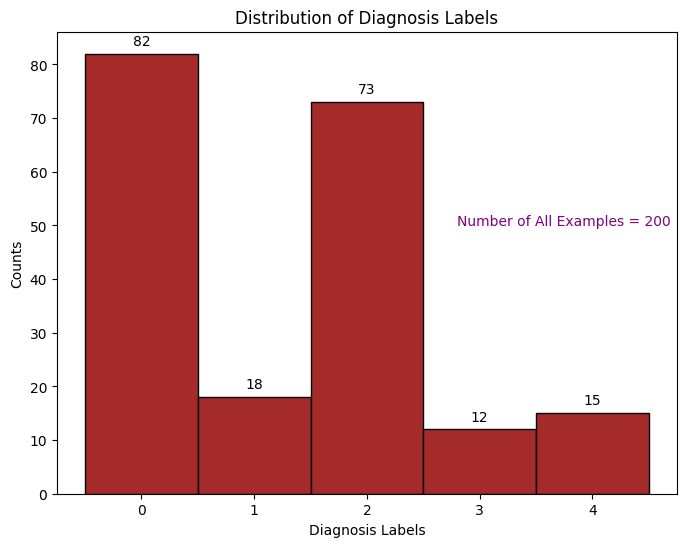

In [192]:
# YOUR CODE HERE

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))

# I'd also like the bars sitting centerized on each class label 
counts, bins, patches = ax.hist(labels.diagnosis,
        bins=np.arange(-0.5, 5.5, 1),
        edgecolor='black',
        color="brown")


# I'd like to show counts for each label
for count, bin_left in zip(counts, bins[:-1]):
    ax.text(bin_left + 0.5, count + 1, str(int(count)),
            ha='center', va='bottom')

# Display axes labels and title
ax.set_xlabel("Diagnosis Labels")
ax.set_ylabel("Counts")
ax.set_title("Distribution of Diagnosis Labels")

ax.set_xticks(range(0, 5))
ax.annotate(xy=(2.8, 50),
            text="Number of All Examples = 200",
            color="purple")
plt.show()


Comment on class balance: [YOUR ANSWER HERE].

 - Class labels are **not balanced**:
    - The majority was diagnosed as label "0", no (sings for) DR. This is expected if the population being screened is the general population (not a particular high-risk group).
    - Other than the class label "No DR" (0), class label "Moderate" (2) has significantly more examples than the other 3 labels. It could be that patients developing DR experience longer duration at this stage.
 - Showing class label distribution before split is okay because: 
    - For a random split, the training, validation, and test samples tend to have the **same (or similar) underlying probability distribution of the class labels**, especially if the split is truly random, and if the sample size is sufficiently large
    - Moreover, the display of distribution **does not reveal any individual example** hence we do not learn anything particular about the test data that is not present in the training data.

#### <span style="color:chocolate"> Exercise 3 (10 points) </span>

Print 8 images from the data. What can you say about the size, focus/orientation of these images?

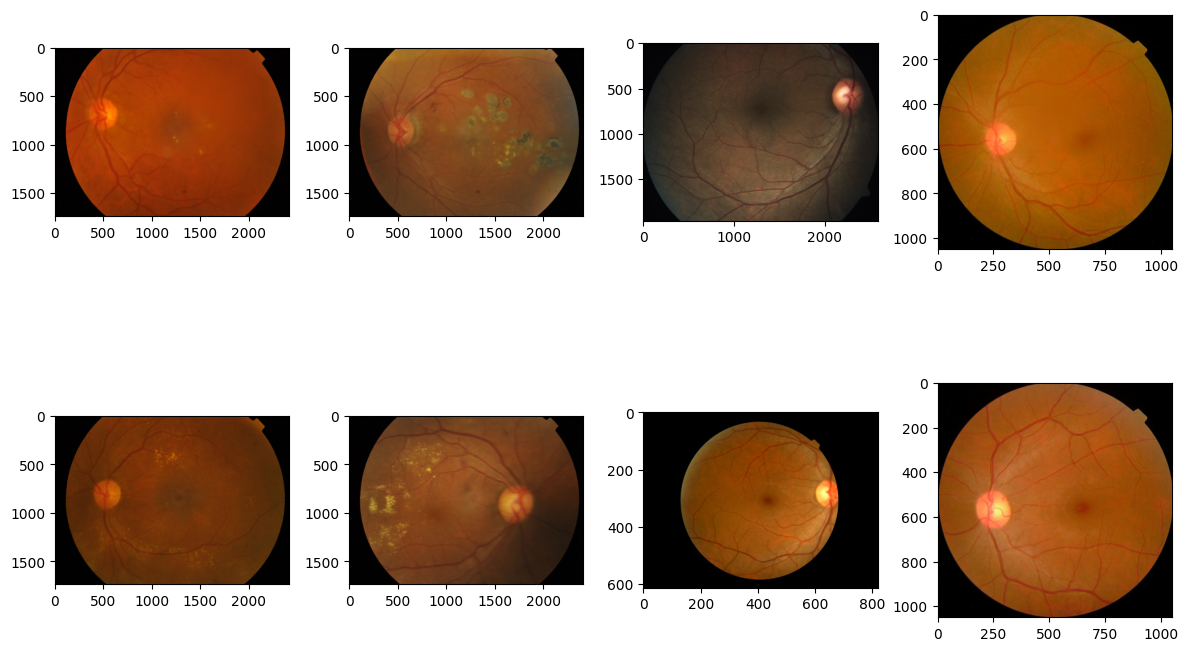

In [193]:
# FILL IN CODE HERE #
# Add a plot in a 2 by 4 grid
fig, ax = plt.subplots(2, 4,
                       figsize=(12, 8))

# Flatten so that we can loop through the axes
ax = ax.flatten()
for i in range(8):
    ax[i].imshow(images[i])

plt.tight_layout()
plt.show()

Comment on the size, focus/orientation of the 8 images: [YOUR ANSWER HERE]

# Ex 3 Comments and Answers

 - Sizes (number of pixels), foci, and orientations are **different across these examples**.
 - It seems, based on the first 8 (or 12, or 16, as I have explored), that examples show a **periodicity of 4** in terms of size, focus, and orientation.
    - If this pattern (for every 4 images) does exist, it is likely due to how examples are organized (by the initial research group, or by the data curator) or how it is sorted.


---
### Step 4: Data preprocessing

First, we will correct for class imbalance. Note that imbalanced data is common in healthcare, and it happens because some diseases are rare. The presence of imbalanced data hampers the detection of rare events as most classification methods implicitly assume a similar occurrence of classes and are designed to maximize the overall classification accuracy.

We will correct for class imbalance in two ways:

  * First, we will binarize the DR diagnosis as follows:
     - 'no refer' are {No DR, mild}
     - 'refer' are {Moderate, Severe, Proliferate}


  * Second, we'll only take 80 random samples from the 'no refer' class and 80 from the 'refer' class.

It is a crude method to deal with imbalanced data, but it will be good enough for this homework. 

In [194]:
np.random.seed(1234)

no_refer = labels[labels.diagnosis.isin((0,1))]
refer = labels[labels.diagnosis.isin((2,3,4))]

# randomly draw 80 images from each classes
temp_no_refer = list(np.random.choice(
    no_refer.id_code,
    size=80,
    replace=False
))

temp_refer = list(np.random.choice(
    refer.id_code,
    size=80,
    replace=False
))

Next, we will use the ``preprocess_data_part1()`` function defined below to generate lists of images and labels (images_mini and y_mini) based on the values in the temp_no_refer and temp_refer lists. Note that the size of the image is set to (224, 224).

In [195]:
def preprocess_data_part1(IMAGE_PATH, LABEL_PATH, temp_no_refer, temp_refer):
    """ Generate lists of images and labelsbased on temp_no_refer and temp_refer lists
    
    Params:
    -------
    IMAGE_PATH (str): path to directory with images.
    LABEL_PATH (str): path to directory with labels.
    temp_no_refer (str): list of labels for the no refer category
    temp_refer (str): list of labels for the refer category
    
    Returns:
    --------
    images_mini  (np.ndarray): Images of shape (N, 224, 224, 3)
    y_mini (np.ndarray): Labels of shape (N,)    
    """
    y_mini = []
    images_mini = []

    # create lists of images and labels `images_mini` and `y_mini` 
    # based on temp_no_refer and temp_refer selections
    for idx, img in enumerate(os.listdir(IMAGE_PATH)):
        # read labels
        if img.split('.')[0] in temp_no_refer:
                y_mini.append(0)
        elif img.split('.')[0] in temp_refer:
                y_mini.append(1)
        else:
            continue

        
        # read image
        img = load_img(
            IMAGE_PATH + img,
            target_size=(224, 224)
        )
        
        # transform image to array
        img = img_to_array(img)

        # append to images
        images_mini.append(img)

    # stack images and trasnform to array
    images_mini = np.stack(images_mini)
    y_mini = np.array(y_mini).flatten() 
    
    return images_mini, y_mini

In [196]:
# generate images and labels based on preprocess_data_part1() function
images_mini, y_mini = preprocess_data_part1(
    IMAGE_PATH, LABEL_PATH, temp_no_refer, temp_refer
)

print(f"images_mini shape {images_mini.shape}")
print(f"y_mini shape {y_mini.shape}")

images_mini shape (160, 224, 224, 3)
y_mini shape (160,)


#### <span style="color:chocolate"> Exercise 4 (20 points) </span>

Create train, validation, and test data. Implement the `preprocess_data_part2()` function according to the following guidelines:

1. shuffle images and labels before splitting the data

2. use a (0.6,0.2,0.2)train/validation/test set split

3. perform image transformation and augmentation, as follows:
    * Applied on training set only:
         - create additional copies (augmentations) of the training images by flipping left right each image (Hint: use the method available in the tf.image module).
         - concatenate the augmented images to the original training images. Note that the train set should be double in size after data augmentation, i.e., 192 images and labels.
    * Applied on training, validation, and test sets:
        - rescale images by dividing each pixel by 255.0

Reason for doing image augmentation: The quantity and diversity of data gathered significantly impact the results of a CNN model. One can use augmentations to artificially inflate the training dataset by warping the original data so that their label does not change. These augmentations can significantly improve learning results without collecting new data.

In [198]:
def preprocess_data_part2(images, labels, splits):
    """ Split data into train, validation and test sets; apply transformaions and augmentations
    
    Params:
    -------
    images  (np.ndarray): Images of shape (N, 224, 224, 3)
    labels (np.ndarray): Labels of shape (N,)   
    splits (tuple): 3 values summing to 1 defining split of train, validation and test sets
    
    Returns:
    --------
    X_train (np.ndarray): Train images of shape (N_train, 224, 224, 3)
    y_train (np.ndarray): Train labels of shape (N_train,)
    X_val (np.ndarray): Val images of shape (N_val, 224, 224, 3)
    y_val (np.ndarray): Val labels of shape (N_val,)
    X_test (np.ndarray): Test images of shape (N_test, 224, 224, 3)
    y_test (np.ndarray): Test labels of shape (N_test,)
    
    """
    
    # NOTE: Each time you run this cell, you'll re-shuffle the data. The ordering will be the same due to the random seed generator 
    tf.random.set_seed(1234)
    np.random.seed(1234)
    
    # shuffle data
    # FILL IN CODE HERE #
    # Create indices
    indices = images.shape[0]
    # Shuffle indices
    indices_shuffled = np.random.permutation(indices)
    # Shuffle data
    images = images[indices_shuffled]
    labels = labels[indices_shuffled]
    
    # create data splits (training, val, and test sets)
    # FILL IN CODE HERE #
    # Get the integer index for boundaries between splitted data
    train_end = int(images.shape[0] * splits[0])
    val_end = train_end + int(images.shape[0] * splits[1])

    # Slice out the datasets
    X_train = images[:train_end]
    X_val = images[train_end:val_end]
    X_test = images[val_end:]

    y_train = labels[:train_end]
    y_val = labels[train_end:val_end]
    y_test = labels[val_end:]

    # image augmentation (random flip) on training data
    X_train_augm =  tf.image.flip_left_right(X_train)

    # concatenate original X_train and augmented X_train_augm data
    X_train = tf.concat([X_train, X_train_augm], axis=0)

    # concatenate y_train (note the label is preserved)
    y_train_augm = y_train
    y_train = tf.concat([y_train, y_train_augm], axis=0)

    # shuffle X_train and y_train, i.e., shuffle two tensors in the same order
    shuffle = tf.random.shuffle(tf.range(tf.shape(X_train)[0], dtype=tf.int32))
    X_train = tf.gather(X_train, shuffle).numpy() # transform X back to numpy array instead of tensor
    y_train = tf.gather(y_train, shuffle).numpy() # transform y back to numpy array instead of tensor

    # rescale training, val, and test images by dividing each pixel by 255.0 
    # FILL IN CODE HERE #
    X_train = X_train / 255.0
    X_val = X_val / 255.0
    X_test = X_test / 255.0
    
    return X_train, y_train, X_val, y_val, X_test, y_test

In [199]:
# define splits
split = (0.6, 0.2, 0.2)

X_train, y_train, X_val, y_val, X_test, y_test = preprocess_data_part2(
    images_mini,
    y_mini,
    split
)

print(f"X_train shape {X_train.shape}")
print(f"y_train shape {y_train.shape}")
print(f"X_val shape {X_val.shape}")
print(f"y_val shape {y_val.shape}")
print(f"X_test shape {X_test.shape}")
print(f"y_test shape {y_test.shape}")

X_train shape (192, 224, 224, 3)
y_train shape (192,)
X_val shape (32, 224, 224, 3)
y_val shape (32,)
X_test shape (32, 224, 224, 3)
y_test shape (32,)


---
### Step 5: Modeling

#### <span style="color:chocolate"> Exercise 5 (20 points) </span>

The objective is to build and train a CNN model to refer patients to doctors based on the severity of DR seen in these images. You are interested in exploring binary classification of 'no refer' and 'refer'.

Implement a CNN classifier according to the following guidelines (let's call this *model_tf*):

1. Implement this model using the TF Keras API.
1. The model receives input images of size 224 x 224 x 3 (that is, the images have three color channels)
2. The input data goes through one convolutional layer that has the following specifications:
    - filters = 12
    - kernel_size = (4 x 4)
    - strides = (1, 1)
    - padding = 'same'
    - data_format = 'channels_last'
    - name = 'conv_1'
    - activation = 'relu'
3. The convolutional layer is followed by a max-pooling layer with pool_size = (2,2). Note: this will reduce the size of the feature maps.
4. The max-pooling layer is followed by a dropout layer with rate = 0.3.
5. The dropout layer is followed by a flattening layer.
6. The last layer of the model is the classification head.
7. Build and compile the model using the Adam optimizer and learning_rate = 0.1. Print summary of the model.
8. Train the model on (X_train, y_train) data for 20 epochs. Add early stopping (Hint: pass the early_stopping implementation below to the fit() method as "callbacks=[early_stopping]").
9. How many parameters does the model have?
10. Generate a plot (for the training and validation data) with the loss values on the y-axis and the epoch number on the x-axis for visualization. Make sure to include axes name and title. Hint: check what the tf.keras.Model.fit() method returns.
11. Evaluate the accuracy of the model on (X_train, y_train) and (X_val, y_val) data. Comment on model performance on training vs. validation datasets. 

In [200]:
# define an instance of the early_stopping class
early_stopping = tf.keras.callbacks.EarlyStopping(
monitor='accuracy', 
verbose=1,
patience=5,
mode='max',
restore_best_weights=True)

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 224, 224, 12)   │           588 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_76 (MaxPooling2D) │ (None, 112, 112, 12)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_76 (Dropout)            │ (None, 112, 112, 12)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_25 (Flatten)            │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 1)              │       150,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151,117 (590.30 KB)

 Trainable params: 151,117 (590.30 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20


/workspaces/207/venv/lib/python3.12/site-packages/keras/src/ops/nn.py:827: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 0.5077 - loss: 1009.8738 - val_accuracy: 0.5625 - val_loss: 0.6835
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.5077 - loss: 0.7026 - val_accuracy: 0.5625 - val_loss: 0.6907
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.5077 - loss: 0.7165 - val_accuracy: 0.5625 - val_loss: 0.6896
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.5077 - loss: 0.7106 - val_accuracy: 0.5625 - val_loss: 0.6855
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.5077 - loss: 0.6992 - val_accuracy: 0.5625 - val_loss: 0.6874
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.5077 - loss: 0.6935 - val_accuracy: 0.5625 - val_loss: 0.6943
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


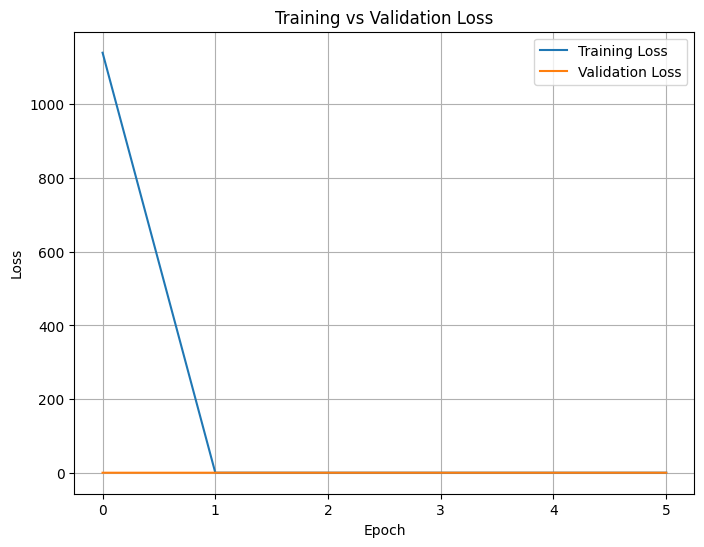

Training Accuracy: 0.500
Validation Accuracy: 0.562


In [201]:

tf.random.set_seed(1234)
np.random.seed(1234)

# initialize model
model_tf = tf.keras.Sequential()

# add convolutional layer
### YOUR CODE HERE ###
model_tf.add(
    tf.keras.layers.Conv2D(
        filters=12,
        kernel_size=(4, 4),
        strides=(1, 1),
        padding='same',
        data_format='channels_last',
        activation='relu',
        name='conv_1'
))

# add max pooling layer 
### YOUR CODE HERE ###
model_tf.add(
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2))
    )

# add dropout layer
### YOUR CODE HERE ###
model_tf.add(
    tf.keras.layers.Dropout(rate=0.3)
    )

# add a flattening layer
### YOUR CODE HERE ###
model_tf.add(
    tf.keras.layers.Flatten()
    )

# add the classification layer
### YOUR CODE HERE ###
model_tf.add(
    tf.keras.layers.Dense(1, activation="softmax")
)

# build and compile model
model_tf.build(input_shape=(None, 224, 224, 3))
model_tf.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy']) 

# print model_tf summary
### YOUR CODE HERE ###
model_tf.summary()

# train model_tf on (X_train, y_train) data
### YOUR CODE HERE ###
history = model_tf.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=[early_stopping],
    verbose=1 
)

# plot loss curves
### YOUR CODE HERE ###
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# evaluate the accuracy of model_tf on (X_train, y_train) and (X_val, y_val)
### YOUR CODE HERE ###
train_loss, train_acc = model_tf.evaluate(X_train, y_train, verbose=0)
val_loss, val_acc = model_tf.evaluate(X_val, y_val, verbose=0)

print(f"Training Accuracy: {train_acc:.3f}")
print(f"Validation Accuracy: {val_acc:.3f}")

How many parameters does *model_tf* have? [YOUR ANSWER HERE]

 - **There are <u>151,117</u> parameters in model_tf**.
    - Convolutional layer: 4 * 4 (kernel) * 3 (color channels) * 12 (filters) + 12 (biases) = 588.
    - Dense layer: 112 * 112 (after-maxpooling) * 12 (filters) + 1 (bias) = 150,529

Comment on *model_tf* accuracy on training vs. validation data: [YOUR ANSWER HERE]

- **The overall accuracy for both training (0.5) and validation (0.562) are not high.**
- **<u>Validation</u> accuracy is <u>bigger</u> than <u>training accuracy</u>, indicating possible underfitting**.

#### <span style="color:chocolate"> Exercise 6 (20 points) </span>

1. Fine-tune the number of hidden layers and the hyperparameters of *model_tf* to determine the setup that yields the most optimal generalization performance. Feel free to explore various model configurations/hyperparameter values.

2. How many parameters does your fine-tuned model have?

3. Evaluate the accuracy of the fine-tuned model on (X_train, y_train) and (X_val, y_val) data. Comment on model performance on training vs. validation datasets.  Is there an improvement compared to the non-fine-tuned version of the model (Exercise 5)?

In [202]:
### YOUR CODE HERE ###

tf.random.set_seed(1234)
np.random.seed(1234)

# Name the model model_tuned
model_tuned = tf.keras.Sequential()

# Adding the first layer with smaller filter (in terms of kernel size)
model_tuned.add(tf.keras.layers.Conv2D(16, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu'))
# Add maxpooling
model_tuned.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))

# Adding a second convolutional layer and maxpooling
# But this time dropout is also added to prevent over fitting
model_tuned.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu'))
model_tuned.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))
model_tuned.add(tf.keras.layers.Dropout(0.2))

# Adding a third convolutional layer
# Note that dropout ratio increases as deeper layers are more susceptible to over fitting
model_tuned.add(tf.keras.layers.Conv2D(64, kernel_size=(2,2), strides=(1,1), padding='same', activation='relu'))
model_tuned.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))
model_tuned.add(tf.keras.layers.Dropout(0.3))

# Adding the dense layer
model_tuned.add(tf.keras.layers.Flatten())
model_tuned.add(tf.keras.layers.Dense(64, activation='relu'))
model_tuned.add(tf.keras.layers.Dropout(0.4))

# Output layer (binary classification)
model_tuned.add(tf.keras.layers.Dense(1, activation='sigmoid'))

# Compile
model_tuned.build(input_shape=(None, 224, 224, 3))
model_tuned.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

# Display model summary
model_tuned.summary()


Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_74 (Conv2D)              │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_77 (MaxPooling2D) │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_75 (Conv2D)              │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_78 (MaxPooling2D) │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_77 (Dropout)            │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (None, 56, 56, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_79 (MaxPooling2D) │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_78 (Dropout)            │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_26 (Flatten)            │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 64)             │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_79 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,224,737 (12.30 MB)

 Trainable params: 3,224,737 (12.30 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Fit the model. 
# Name the results "history_2"

# Set seeds
tf.random.set_seed(1234)
np.random.seed(1234)

history_2 = model_tuned.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=[early_stopping],
    verbose=1 
)

Epoch 1/20


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step - accuracy: 0.9219 - loss: 0.1908 - val_accuracy: 0.9375 - val_loss: 0.2571
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 205ms/step - accuracy: 0.9251 - loss: 0.1780 - val_accuracy: 0.9375 - val_loss: 0.2624
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step - accuracy: 0.9177 - loss: 0.1674 - val_accuracy: 0.9062 - val_loss: 0.2466
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step - accuracy: 0.9290 - loss: 0.1532 - val_accuracy: 0.9062 - val_loss: 0.2503
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step - accuracy: 0.9634 - loss: 0.1220 - val_accuracy: 0.8750 - val_loss: 0.3279
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step - accuracy: 0.9323 - loss: 0.1640 - val_accuracy: 0.9062 - val_loss: 0.2815
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step - accuracy: 0.9527 - loss: 0.1350 - val_accuracy: 0.9062 - val_loss: 0.3133
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - accuracy: 0.9551 - loss: 0.1445 - val_accuracy: 0.9375 - val_loss: 0.3648
Epo

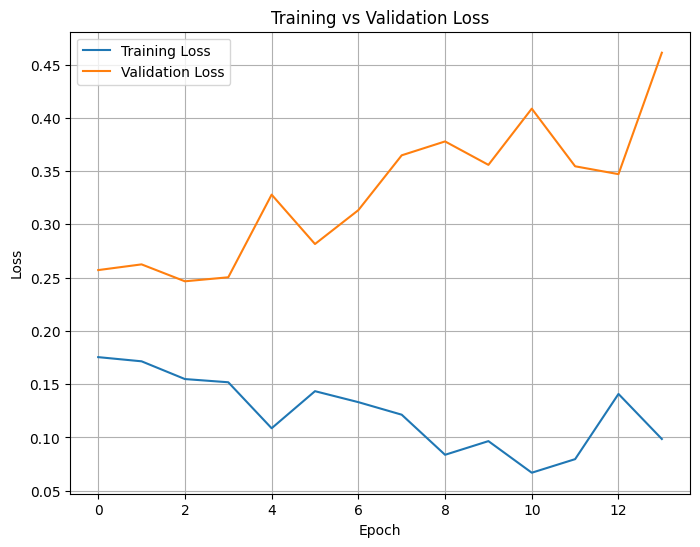

Training Accuracy AFTER TUNING: 0.984
Validation Accuracy AFTER TUNING: 0.938


In [207]:
plt.figure(figsize=(8, 6))
plt.plot(history_2.history['loss'], label='Training Loss')
plt.plot(history_2.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# evaluate the accuracy of model_tf on (X_train, y_train) and (X_val, y_val)
### YOUR CODE HERE ###
train_loss, train_acc = model_tuned.evaluate(X_train, y_train, verbose=0)
val_loss, val_acc = model_tuned.evaluate(X_val, y_val, verbose=0)

print(f"Training Accuracy AFTER TUNING: {train_acc:.3f}")
print(f"Validation Accuracy AFTER TUNING: {val_acc:.3f}")

How many parameters does your fine-tuned model have? [YOUR ANSWER HERE]

 - There are **3,224,737** (trainable) parameters. In tuning, I found that there are some configurations that would drastically reduce the number of of parameters (to about 1/8) that would only result in minor decrease in accuracy. But since compute constraint is not a concern in this case, I prefer the model that yield the most preferrable training and validation accuracy. 

Comment on accuracy of the fine-tuned model on training vs. validation performance. Is there an improvement over the non-fine-tuned version? [YOUR ANSWER HERE]

 - As shown in the above print-outs:
    - **Training accuracy: <u>0.984</u>**
    - **Validation accuracy: <u>0.938</u>**
 - First of all with the tuned model, the **accuracies improved** significantly as compared to the baseline model. 
 - The training accuracy is slightly higher than the validation, indicating **slight overfitting**, which is desired according to our lectures. 


---
### Step 6: Evaluation

#### <span style="color:chocolate"> Exercise 7 (10 points) </span>

You will now use the test data to evaluate the performance (accuracy) of your fine-tuned model on unseen data. Does your model generalize wel

In [209]:
### YOUR CODE HERE ###

# Use two methods (making sure calculation is likely to be correct)
# Method 1 sklearn method
y_pred = (model_tuned.predict(X_test) > 0.5).astype(int).reshape(-1)
test_acc = accuracy_score(y_test, y_pred)
print("Method 1 - test accuracy using sklearn accuracy_score method", test_acc)

# Method 2
test_loss, test_acc = model_tuned.evaluate(X_test, y_test, verbose=0)
print(f"Method 2 - test accuracy using the evaluate() method: {test_acc:.3f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Method 1 - test accuracy using sklearn accuracy_score method 0.875
Method 2 - test accuracy using the evaluate() method: 0.875


Does your model generalize well? [YOUR ANSWER HERE]

 - The model generalizes **reasonably well** with <u>**87.5%**</u> accuracy.
 - However, note that the test accuracy is about 13% lower than that of the training and 7% lower than validation. Not too bad.
 - (On randomness) I note that there are only 32 validation examples and 32 test examples. Hence, a difference in 4 correct/wrong predictions in the test data would result in a 12.5 percentage point differenece in accuracy score.
